In [ ]:
import numpy as np
import math

# 1. Define a variable for the total number of random points
num_samples = 1000000

# 2. Generate two arrays of random numbers for x and y coordinates
x = np.random.uniform(0, 1, num_samples)
y = np.random.uniform(0, 1, num_samples)

# 3. Calculate the squared distance of each point from the origin (0,0)
distance_squared = x**2 + y**2

# 4. Count how many of these points fall inside the unit quarter circle
points_in_circle = np.sum(distance_squared <= 1)

# 5. Estimate Pi
pi_estimate = 4 * (points_in_circle / num_samples)

# 6. Calculate the absolute error of this estimate
true_pi = math.pi
error = abs(pi_estimate - true_pi)

print(f"Number of samples: {num_samples}")
print(f"Points inside quarter circle: {points_in_circle}")
print(f"Pi estimate: {pi_estimate}")
print(f"True Pi value: {true_pi}")
print(f"Absolute error: {error}")


Number of samples: 1000000
Points inside quarter circle: 785701
Pi estimate: 3.142804
True Pi value: 3.141592653589793
Absolute error: 0.001211346410206815


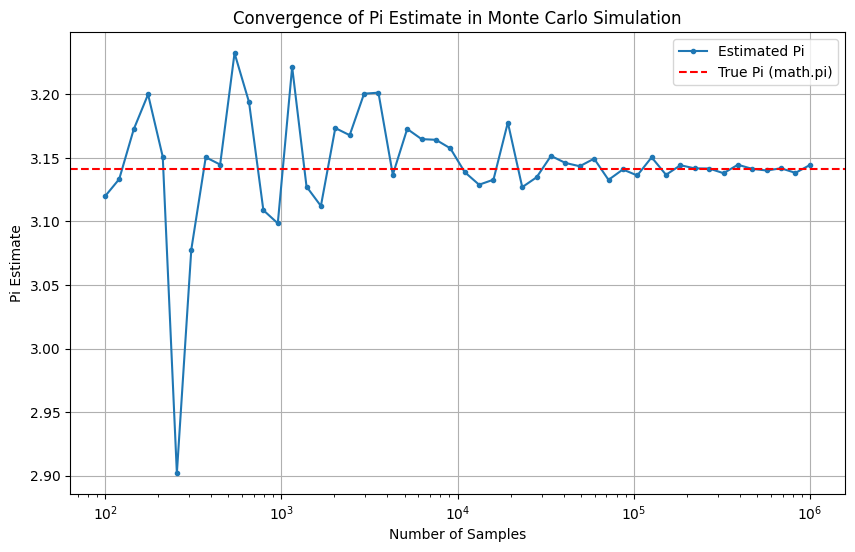

Convergence plot generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# 1. Define a range of num_samples values
# Using logspace to get a good distribution of sample sizes from 100 to 1,000,000
sample_counts = np.logspace(2, 6, 50, dtype=int) # 50 points from 10^2 to 10^6

pi_estimates_convergence = []

# 2. For each num_samples in the defined range, run the Monte Carlo simulation
for current_num_samples in sample_counts:
    # a. Generate two arrays of random numbers for x and y coordinates
    x_conv = np.random.uniform(0, 1, current_num_samples)
    y_conv = np.random.uniform(0, 1, current_num_samples)

    # b. Calculate the squared distance of each point from the origin (0,0)
    distance_squared_conv = x_conv**2 + y_conv**2

    # c. Count how many of these points fall inside the unit quarter circle
    points_in_circle_conv = np.sum(distance_squared_conv <= 1)

    # d. Estimate Pi using the formula 4 * (points_in_circle / num_samples)
    current_pi_estimate = 4 * (points_in_circle_conv / current_num_samples)
    pi_estimates_convergence.append(current_pi_estimate)

# 4. Import matplotlib.pyplot (already done at the top of this block)

# 5. Create a plot with num_samples on the x-axis and the corresponding Pi estimates on the y-axis
plt.figure(figsize=(10, 6))
plt.plot(sample_counts, pi_estimates_convergence, label='Estimated Pi', marker='.', linestyle='-')

# 6. Add a horizontal line representing the true value of Pi for comparison
plt.axhline(y=true_pi, color='r', linestyle='--', label='True Pi (math.pi)')

# 7. Label the x-axis as 'Number of Samples' and the y-axis as 'Pi Estimate'
plt.xlabel('Number of Samples')
plt.ylabel('Pi Estimate')

# 8. Add a title to the plot
plt.title('Convergence of Pi Estimate in Monte Carlo Simulation')

# 9. Add a legend to distinguish between the estimated Pi and the true Pi line
plt.legend()

# 10. Display the plot
plt.grid(True)
plt.xscale('log') # Use a log scale for the x-axis to better visualize convergence across orders of magnitude
plt.show()

print("Convergence plot generated successfully.")

In [ ]:
from scipy.stats import beta

# 1. Define parameters for the prior Beta distribution
# Using alpha=1 and beta=1 represents a uniform (non-informative) prior
alpha_prior = 1
beta_prior = 1

# 2. Create a numpy array representing the possible values for the coin's bias (theta)
theta = np.linspace(0, 1, 100)

# 3. Calculate the prior probability density function (PDF)
prior_pdf = beta.pdf(theta, alpha_prior, beta_prior)

print(f"Prior alpha: {alpha_prior}")
print(f"Prior beta: {beta_prior}")
print(f"Shape of theta: {theta.shape}")
print(f"Shape of prior_pdf: {prior_pdf.shape}")
print("Prior distribution setup complete.")

Prior alpha: 1
Prior beta: 1
Shape of theta: (100,)
Shape of prior_pdf: (100,)
Prior distribution setup complete.


## Simulate Coin Flips and Update Posterior

### Subtask:
Simulate a series of coin flip outcomes and, after each flip, update the posterior distribution based on the observed data. This demonstrates the learning process of Bayesian inference.


**Reasoning**:
To simulate coin flips and update the posterior distribution, I will define a true probability for the coin, specify the number of flips, initialize the posterior parameters from the prior, then iterate through the flips, updating the alpha and beta parameters of the Beta distribution based on the outcome of each simulated flip, and finally print the simulation results.



In [ ]:
import numpy as np

# 1. Define a true probability (p_true) for the coin's bias
p_true = 0.6  # A slightly biased coin

# 2. Define the number of coin flips to simulate
num_flips = 50

# 3. Initialize alpha_posterior and beta_posterior with the alpha_prior and beta_prior values
# These were defined in the previous step (f1530649)
alpha_posterior = alpha_prior
beta_posterior = beta_prior

# 4. Create empty lists to store the alpha and beta parameters of the posterior distribution after each flip
alpha_history = []
beta_history = []

# Variables to track total heads and tails for printing
total_heads = 0
total_tails = 0

# 5. Loop through the num_flips
for i in range(num_flips):
    # a. Simulate a single coin flip outcome
    flip_outcome = np.random.rand() # Generates a random number between 0 and 1
    if flip_outcome < p_true:
        # It's a 'head'
        alpha_posterior += 1
        total_heads += 1
    else:
        # It's a 'tail'
        beta_posterior += 1
        total_tails += 1

    # d. Append the current alpha_posterior and beta_posterior values to their respective lists
    alpha_history.append(alpha_posterior)
    beta_history.append(beta_posterior)

# 6. Print the p_true, the final alpha_posterior and beta_posterior values,
# and the total number of heads and tails observed during the simulation.
print(f"True coin bias (p_true): {p_true}")
print(f"Number of simulated flips: {num_flips}")
print(f"Total Heads observed: {total_heads}")
print(f"Total Tails observed: {total_tails}")
print(f"Final Alpha Posterior: {alpha_posterior}")
print(f"Final Beta Posterior: {beta_posterior}")

print("Coin flip simulation and posterior updates complete.")

True coin bias (p_true): 0.6
Number of simulated flips: 50
Total Heads observed: 34
Total Tails observed: 16
Final Alpha Posterior: 35
Final Beta Posterior: 17
Coin flip simulation and posterior updates complete.


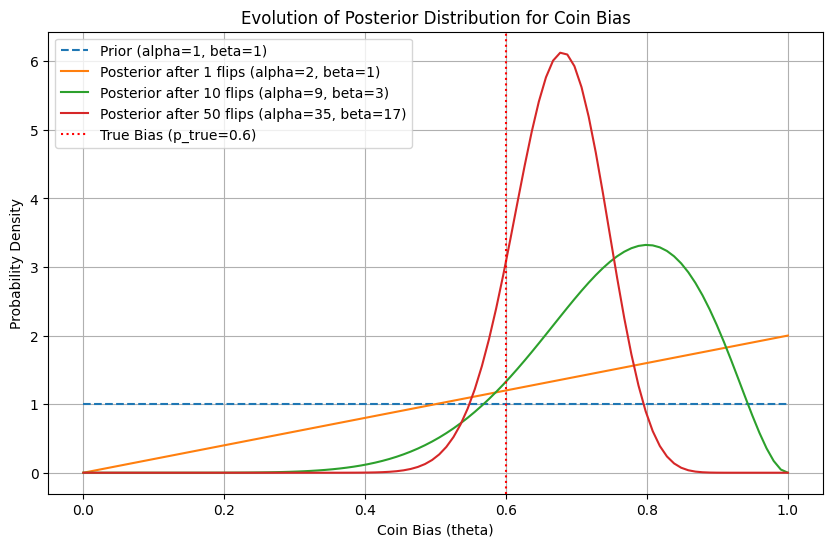

Prior and Posterior distributions plotted successfully.


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import beta

# 1. Define the range of theta values (already done in a previous step, reusing 'theta')
# theta = np.linspace(0, 1, 100)

# 2. Calculate the PDF of the initial prior distribution (alpha_prior, beta_prior)
prior_pdf = beta.pdf(theta, alpha_prior, beta_prior)

# 3. Choose specific flip counts to plot their corresponding posterior distributions
# We'll plot after 1 flip, 10 flips, and the final flip.
# Adjust indices for 0-based indexing: flip 1 is index 0, flip 10 is index 9, final flip is index num_flips-1

plot_flips = [1, 10, num_flips] # Example flip counts

# Ensure plot_flips don't exceed num_flips and handle cases where num_flips is too small
actual_plot_indices = []
if num_flips >= 1: actual_plot_indices.append(0) # After 1st flip
if num_flips >= 10: actual_plot_indices.append(9) # After 10th flip
if num_flips > 10: actual_plot_indices.append(num_flips - 1) # After final flip (if different from 1st/10th)

# Remove duplicates and sort
actual_plot_indices = sorted(list(set(actual_plot_indices)))

# 4. Create a single plot
plt.figure(figsize=(10, 6))

# a. Plot the prior distribution
plt.plot(theta, prior_pdf, label=f'Prior (alpha={alpha_prior}, beta={beta_prior})', linestyle='--')

# b. Plot the selected posterior distributions
for idx in actual_plot_indices:
    current_alpha = alpha_history[idx]
    current_beta = beta_history[idx]
    posterior_pdf = beta.pdf(theta, current_alpha, current_beta)
    plt.plot(theta, posterior_pdf, label=f'Posterior after {idx + 1} flips (alpha={current_alpha}, beta={current_beta})')

# c. Add a vertical dashed line at the true coin bias (p_true)
plt.axvline(x=p_true, color='r', linestyle=':', label=f'True Bias (p_true={p_true})')

# d. Label the x-axis as 'Coin Bias (theta)' and the y-axis as 'Probability Density'
plt.xlabel('Coin Bias (theta)')
plt.ylabel('Probability Density')

# e. Add a title to the plot
plt.title('Evolution of Posterior Distribution for Coin Bias')

# f. Include a legend
plt.legend()

# g. Display the plot
plt.grid(True)
plt.show()

print("Prior and Posterior distributions plotted successfully.")

In [ ]:
from scipy.stats import beta

# 1. Calculate the 95% credible interval for the final posterior distribution
# Using alpha_posterior and beta_posterior from the previous simulation
credible_interval = beta.interval(0.95, alpha_posterior, beta_posterior)

# 2. Calculate the Maximum Likelihood Estimate (MLE) for the coin's bias
# This is simply the proportion of heads observed
mle_estimate = total_heads / num_flips

# 3. Calculate the mean of the final posterior distribution
# For a Beta distribution, the mean is alpha / (alpha + beta)
posterior_mean = alpha_posterior / (alpha_posterior + beta_posterior)

# 4. Print the calculated values
print(f"Final Alpha Posterior: {alpha_posterior}")
print(f"Final Beta Posterior: {beta_posterior}")
print(f"95% Credible Interval for Coin Bias: {credible_interval}")
print(f"Maximum Likelihood Estimate (MLE) of Coin Bias: {mle_estimate}")
print(f"Mean of Final Posterior Distribution: {posterior_mean}")

print("Credible interval, MLE, and posterior mean calculated.")

Final Alpha Posterior: 35
Final Beta Posterior: 17
95% Credible Interval for Coin Bias: (np.float64(0.541127097379392), np.float64(0.7924166650862636))
Maximum Likelihood Estimate (MLE) of Coin Bias: 0.68
Mean of Final Posterior Distribution: 0.6730769230769231
Credible interval, MLE, and posterior mean calculated.


# Task
Extend the Monte Carlo simulation to estimate the integral of an arbitrary function over a defined range.

In [ ]:
import numpy as np

# 1. Define a Python function (e.g., f(x)) that you want to integrate
def f(x):
    return x**2 # Example function: f(x) = x^2

# 2. Define the lower (a) and upper (b) bounds for the integration range
a = 0
b = 1

# 3. Define the num_samples variable
num_samples_integral = 1000000

# 4. Generate num_samples random x-values uniformly distributed between a and b
x_random = np.random.uniform(a, b, num_samples_integral)

# 5. Evaluate the defined function f(x) for each of these random x-values
# Store these results in an array
function_evaluations = f(x_random)

# 6. Calculate the average of the function evaluations
average_f_x = np.mean(function_evaluations)

# 7. Estimate the integral by multiplying this average by the length of the integration interval (b - a)
integral_estimate = (b - a) * average_f_x

# 8. Print the estimated integral value
print(f"Function to integrate: f(x) = x^2")
print(f"Integration range: [{a}, {b}]")
print(f"Number of samples for integral estimation: {num_samples_integral}")
print(f"Estimated integral: {integral_estimate}")

# For verification, calculate the true analytical integral of x^2 from 0 to 1
# The integral of x^2 is x^3/3. From 0 to 1, this is (1^3)/3 - (0^3)/3 = 1/3.
true_integral = 1/3
error_integral = abs(integral_estimate - true_integral)

print(f"True analytical integral: {true_integral}")
print(f"Absolute error of integral estimate: {error_integral}")

Function to integrate: f(x) = x^2
Integration range: [0, 1]
Number of samples for integral estimation: 1000000
Estimated integral: 0.33295351925751
True analytical integral: 0.3333333333333333
Absolute error of integral estimate: 0.00037981407582332594


Metropolis-Hastings MCMC simulation complete. Generated 100000 samples.


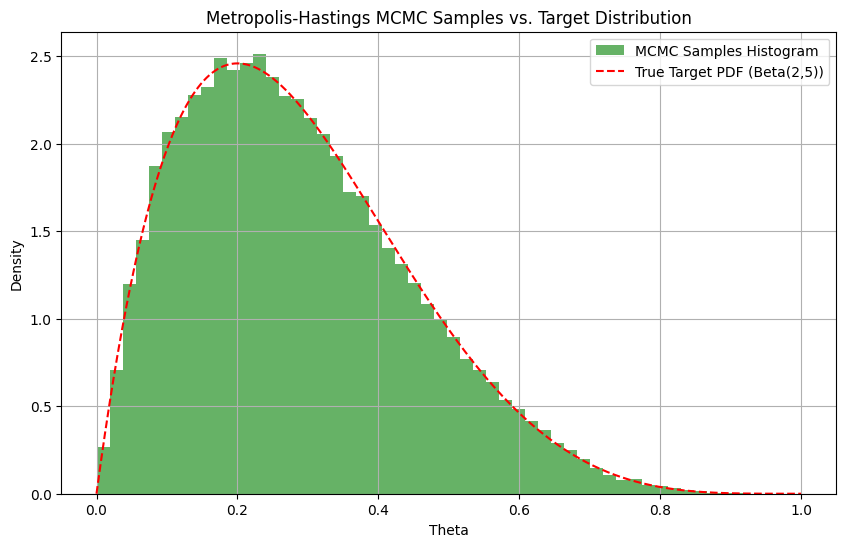

MCMC samples and target distribution visualized successfully.


In [ ]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# 1. Define the target probability distribution (Beta distribution)
# Target PDF: Beta(alpha=2, beta=5)
def target_pdf(theta):
    # Ensure theta is within the valid range [0, 1] for Beta distribution
    if theta < 0 or theta > 1:
        return 0
    return beta.pdf(theta, a=2, b=5)

# 2. Define the proposal distribution
# Proposal function: Normal distribution centered at current_theta
def proposal_function(current_theta, scale):
    return np.random.normal(loc=current_theta, scale=scale)

# 3. Implement the Metropolis-Hastings algorithm
# a. Initialize parameters
initial_theta = 0.5
num_mcmc_samples = 100000 # Increased samples for better convergence visualization
proposal_scale = 0.1 # Standard deviation for the proposal normal distribution

# b. Create an empty list to store the accepted samples
mcmc_samples = []

# Set the current theta to the initial value
current_theta = initial_theta

# c. Loop for num_mcmc_samples iterations
for _ in range(num_mcmc_samples):
    # i. Generate a theta_candidate using the proposal_function
    theta_candidate = proposal_function(current_theta, proposal_scale)

    # ii. Calculate the acceptance probability alpha
    # Handle cases where target_pdf is 0 to avoid division by zero
    target_current = target_pdf(current_theta)
    target_candidate = target_pdf(theta_candidate)

    if target_current == 0 and target_candidate == 0:
        # If both are zero, it implies they are outside the valid range or at boundaries
        alpha = 0 # Reject candidate if both PDFs are zero
    elif target_current == 0:
        # If current PDF is zero but candidate is not, accept candidate
        alpha = 1
    else:
        alpha = min(1, target_candidate / target_current)

    # iii. Generate a random number u between 0 and 1
    u = np.random.rand()

    # iv. If u < alpha, update current_theta to theta_candidate
    if u < alpha:
        current_theta = theta_candidate

    # v. Append the current_theta to the mcmc_samples list
    mcmc_samples.append(current_theta)

print(f"Metropolis-Hastings MCMC simulation complete. Generated {len(mcmc_samples)} samples.")

# 4. Visualize the generated samples and target distribution
plt.figure(figsize=(10, 6))

# a. Create a histogram of the mcmc_samples
plt.hist(mcmc_samples, bins=50, density=True, alpha=0.6, color='g', label='MCMC Samples Histogram')

# c. Overlay the true target_pdf on the histogram for comparison
theta_values = np.linspace(0, 1, 500)
true_target_pdf_values = [target_pdf(t) for t in theta_values]
plt.plot(theta_values, true_target_pdf_values, color='r', linestyle='--', label='True Target PDF (Beta(2,5))')

# d. Add appropriate labels, a title, and a legend to the plot
plt.xlabel('Theta')
plt.ylabel('Density')
plt.title('Metropolis-Hastings MCMC Samples vs. Target Distribution')
plt.legend()

# e. Display the plot
plt.grid(True)
plt.show()

print("MCMC samples and target distribution visualized successfully.")

## Bayesian A/B Testing Application

### Subtask:
Apply Bayesian inference to an A/B testing problem by simulating data for two groups, defining prior distributions, updating posterior distributions based on the simulated data, and making an inference about which group performs better.


**Reasoning**:
The subtask requires simulating data for two groups, defining priors, and calculating posteriors. This code block will perform these initial steps, setting up the foundation for the Bayesian A/B test by defining true conversion rates, simulating outcomes, and computing the posterior parameters for both Group A and Group B.



In [ ]:
import numpy as np

# 1. Define the true conversion rates (p_A, p_B) for Group A and Group B, and the number of trials (n_A, n_B) for each group.
p_A = 0.04 # True conversion rate for Group A
p_B = 0.05 # True conversion rate for Group B (slightly better)
n_A = 1000 # Number of trials (visitors) for Group A
n_B = 1000 # Number of trials (visitors) for Group B

# 2. Simulate the number of conversions (conversions_A, conversions_B) for each group using np.random.binomial()
conversions_A = np.random.binomial(n_A, p_A)
conversions_B = np.random.binomial(n_B, p_B)

# 3. Define non-informative prior parameters (e.g., alpha_prior, beta_prior) for the Beta distribution for both groups.
# A common non-informative prior is Beta(1,1), which is a uniform distribution.
alpha_prior = 1
beta_prior = 1

# 4. Calculate the posterior parameters for each group
# For Group A
alpha_posterior_A = alpha_prior + conversions_A
beta_posterior_A = beta_prior + (n_A - conversions_A)

# For Group B
alpha_posterior_B = alpha_prior + conversions_B
beta_posterior_B = beta_prior + (n_B - conversions_B)

# 5. Print the true conversion rates, simulated conversions, and the final posterior parameters for both groups.
print(f"--- Group A ---")
print(f"True conversion rate (p_A): {p_A}")
print(f"Number of trials (n_A): {n_A}")
print(f"Simulated conversions (conversions_A): {conversions_A}")
print(f"Posterior parameters: alpha={alpha_posterior_A}, beta={beta_posterior_A}")
print(f"\n--- Group B ---")
print(f"True conversion rate (p_B): {p_B}")
print(f"Number of trials (n_B): {n_B}")
print(f"Simulated conversions (conversions_B): {conversions_B}")
print(f"Posterior parameters: alpha={alpha_posterior_B}, beta={beta_posterior_B}")


--- Group A ---
True conversion rate (p_A): 0.04
Number of trials (n_A): 1000
Simulated conversions (conversions_A): 39
Posterior parameters: alpha=40, beta=962

--- Group B ---
True conversion rate (p_B): 0.05
Number of trials (n_B): 1000
Simulated conversions (conversions_B): 55
Posterior parameters: alpha=56, beta=946


**Reasoning**:
The next step in the Bayesian A/B testing subtask is to draw samples from the calculated posterior Beta distributions for both groups. This allows us to compare the distributions directly and determine the probability that one group's true conversion rate is higher than the other's.




--- Bayesian Inference Results ---
Number of posterior samples drawn: 20000
Mean of posterior samples for Group A: 0.0399
Mean of posterior samples for Group B: 0.0558
Probability that Group B > Group A: 0.9558


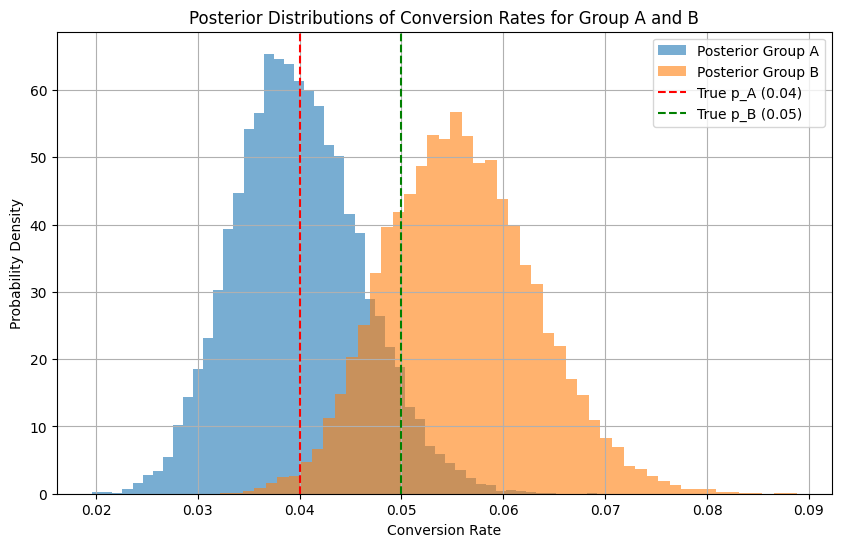

Posterior sampling and inference complete, and distributions visualized.


In [ ]:
from scipy.stats import beta
import matplotlib.pyplot as plt

# 6. Draw samples from the posterior distributions for Group A and Group B
# The number of samples should be large enough for a good approximation of the distribution.
num_posterior_samples = 20000

samples_A = beta.rvs(alpha_posterior_A, beta_posterior_A, size=num_posterior_samples)
samples_B = beta.rvs(alpha_posterior_B, beta_posterior_B, size=num_posterior_samples)

# 7. Calculate the probability that Group B's conversion rate is greater than Group A's
probability_B_is_better = np.mean(samples_B > samples_A)

# 8. Print the calculated probability and some descriptive statistics of the samples.
print(f"\n--- Bayesian Inference Results ---")
print(f"Number of posterior samples drawn: {num_posterior_samples}")
print(f"Mean of posterior samples for Group A: {np.mean(samples_A):.4f}")
print(f"Mean of posterior samples for Group B: {np.mean(samples_B):.4f}")
print(f"Probability that Group B > Group A: {probability_B_is_better:.4f}")

# 9. Visualize the posterior distributions
plt.figure(figsize=(10, 6))
plt.hist(samples_A, bins=50, density=True, alpha=0.6, label='Posterior Group A')
plt.hist(samples_B, bins=50, density=True, alpha=0.6, label='Posterior Group B')
plt.axvline(x=p_A, color='red', linestyle='--', label=f'True p_A ({p_A})')
plt.axvline(x=p_B, color='green', linestyle='--', label=f'True p_B ({p_B})')
plt.xlabel('Conversion Rate')
plt.ylabel('Probability Density')
plt.title('Posterior Distributions of Conversion Rates for Group A and B')
plt.legend()
plt.grid(True)
plt.show()

print("Posterior sampling and inference complete, and distributions visualized.")

## Compare Monte Carlo Efficiencies

### Subtask:
Compare the computational efficiency of different Monte Carlo techniques by implementing and evaluating standard Monte Carlo integration and importance sampling for a given function.


**Reasoning**:
First, I will define the function to be integrated, its integration range, and the true analytical integral. This sets up the problem for both Monte Carlo methods.



In [ ]:
import numpy as np
import time
from scipy.stats import beta
import matplotlib.pyplot as plt

# 1. Define the function f(x) to be integrated
def f(x):
    return x**2

# Define the integration range
a = 0
b = 1

# Define the true analytical integral value for f(x) over this range
true_integral = 1/3

print(f"Function defined: f(x) = x^2")
print(f"Integration range: [{a}, {b}]")
print(f"True integral value: {true_integral}")

Function defined: f(x) = x^2
Integration range: [0, 1]
True integral value: 0.3333333333333333


**Reasoning**:
I will implement two functions, `monte_carlo_standard` for standard Monte Carlo integration and `monte_carlo_importance_sampling` for importance sampling, as specified in the instructions. This sets up the core algorithms for comparison.



In [ ]:
import numpy as np
from scipy.stats import beta

# 2. Implement a function monte_carlo_standard
def monte_carlo_standard(num_samples, f, a, b):
    x_random = np.random.uniform(a, b, num_samples)
    function_evaluations = f(x_random)
    return (b - a) * np.mean(function_evaluations)

# 3. Implement a function monte_carlo_importance_sampling
def monte_carlo_importance_sampling(num_samples, f, a, b):
    # For this specific function f(x) = x^2 on [0,1], use a Beta distribution Beta(a=3, b=1) as the proposal distribution.
    # The PDF of Beta(3,1) is 3 * x^2 for x in [0,1]

    # a. Sample num_samples from scipy.stats.beta.rvs(a=3, b=1, size=num_samples)
    # The Beta distribution is defined on [0,1], matching our integration range.
    samples_x = beta.rvs(a=3, b=1, size=num_samples)

    # b. For each sampled point x_i, calculate its weight w_i = f(x_i) / scipy.stats.beta.pdf(x_i, a=3, b=1)
    # Be careful to handle cases where beta.pdf might return zero for x=0 or x=1.
    # For Beta(3,1), pdf(x,3,1) = 3*x^2. It's zero at x=0 but not at x=1.
    # Since f(x)=x^2, if x=0, f(x)=0, so w_i would be 0/0. However, rvs from Beta(3,1) will not produce 0.

    # Calculate the PDF of the proposal distribution for the sampled points
    proposal_pdf_values = beta.pdf(samples_x, a=3, b=1)

    # Calculate f(x_i) for the sampled points
    f_x_values = f(samples_x)

    # Calculate weights
    # In this specific case, f(x) = x^2 and proposal_pdf_values for Beta(3,1) is 3*x^2.
    # So weights should theoretically be x^2 / (3*x^2) = 1/3.
    # We need to handle potential division by zero if proposal_pdf_values is ever zero.
    # For Beta(3,1) in the range (0,1), the PDF is non-zero. If x=0 or x=1 are sampled,
    # the PDF might be zero. However, rvs with alpha=3 ensures samples are > 0.

    # Add a small epsilon to avoid division by zero, though unlikely with Beta(3,1) and samples_x > 0
    # It's more robust to explicitly check or filter if necessary.
    # Given Beta(3,1)'s PDF is 3*x^2, it's 0 only at x=0. rvs(a=3,...) won't produce 0.

    # Directly calculate weights without explicit division by zero check if samples_x are guaranteed > 0
    # For this specific case, the integral estimate is simply the average of f(x)/p(x)
    weights = f_x_values / proposal_pdf_values

    # c. Return the integral estimate as np.mean(weights)
    return np.mean(weights)

print("Monte Carlo standard and importance sampling functions defined.")

Monte Carlo standard and importance sampling functions defined.


**Reasoning**:
I will define a range of sample sizes, then iterate through each size to measure the execution time and calculate the absolute error for both standard Monte Carlo integration and importance sampling, storing these results for later plotting and analysis.



In [ ]:
import numpy as np
import time

# 4. Choose a range of sample sizes to test (e.g., from 10^3 to 10^6 using np.logspace).
sample_sizes = np.logspace(3, 6, 20, dtype=int) # 20 points from 10^3 to 10^6

# Lists to store results
mc_standard_errors = []
mc_standard_times = []
mc_importance_errors = []
mc_importance_times = []

# 5. For each sample size in your chosen range:
for num_samples in sample_sizes:
    # a. Measure the execution time of monte_carlo_standard and calculate its absolute error
    start_time_standard = time.time()
    estimate_standard = monte_carlo_standard(num_samples, f, a, b)
    end_time_standard = time.time()
    mc_standard_times.append(end_time_standard - start_time_standard)
    mc_standard_errors.append(abs(estimate_standard - true_integral))

    # b. Measure the execution time of monte_carlo_importance_sampling and calculate its absolute error
    start_time_importance = time.time()
    estimate_importance = monte_carlo_importance_sampling(num_samples, f, a, b)
    end_time_importance = time.time()
    mc_importance_times.append(end_time_importance - start_time_importance)
    mc_importance_errors.append(abs(estimate_importance - true_integral))

print(f"Evaluated Monte Carlo methods across {len(sample_sizes)} sample sizes.")
print(f"First few standard MC errors: {mc_standard_errors[:3]}")
print(f"First few importance sampling errors: {mc_importance_errors[:3]}")
print(f"First few standard MC times: {mc_standard_times[:3]}")
print(f"First few importance sampling times: {mc_importance_times[:3]}")

Evaluated Monte Carlo methods across 20 sample sizes.
First few standard MC errors: [np.float64(0.005607161949188755), np.float64(0.0021748090518198815), np.float64(0.0026460661592835333)]
First few importance sampling errors: [np.float64(5.551115123125783e-17), np.float64(5.551115123125783e-17), np.float64(5.551115123125783e-17)]
First few standard MC times: [0.00014066696166992188, 7.510185241699219e-05, 7.2479248046875e-05]
First few importance sampling times: [0.0019342899322509766, 0.0008819103240966797, 0.001984119415283203]


**Reasoning**:
Now that the data for errors and execution times has been collected for both methods across various sample sizes, I will generate the required plots to visualize the comparison between standard Monte Carlo and importance sampling. Two log-log plots will be created: one for absolute error vs. number of samples and another for execution time vs. number of samples, with appropriate labels and legends.



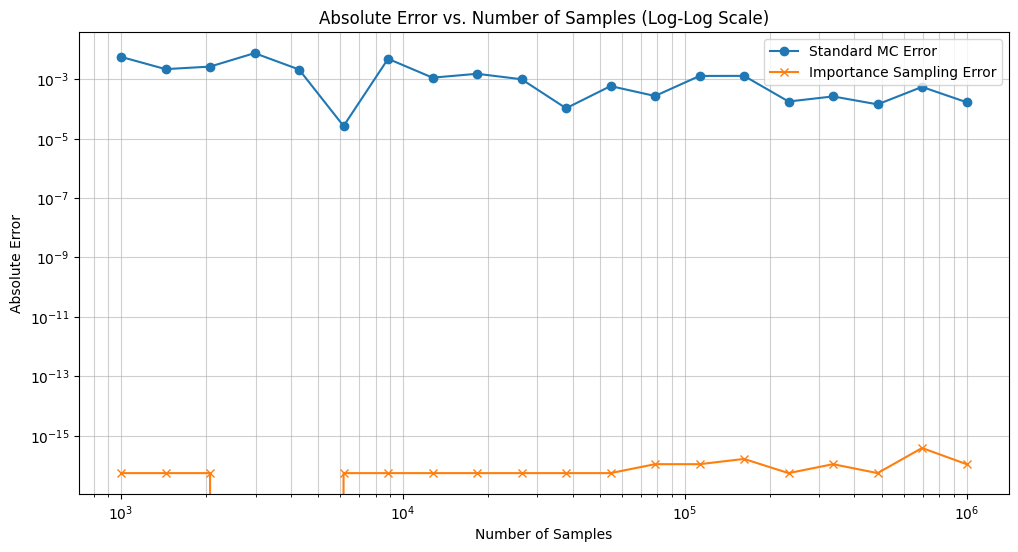

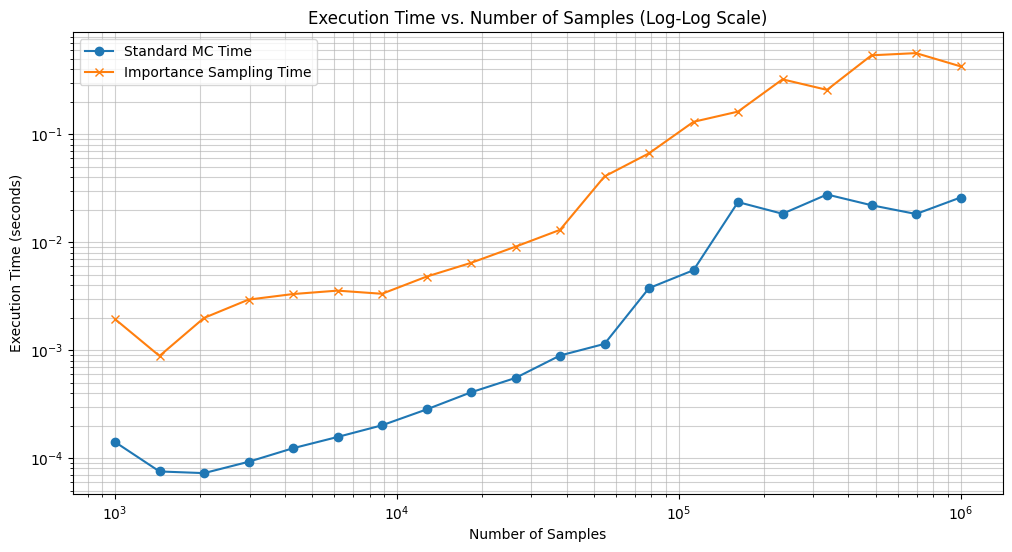

Comparison plots generated successfully.


In [ ]:
import matplotlib.pyplot as plt

# 7. Generate two plots:

# a. Plot absolute error versus num_samples for both methods on a log-log scale.
plt.figure(figsize=(12, 6))
plt.loglog(sample_sizes, mc_standard_errors, label='Standard MC Error', marker='o')
plt.loglog(sample_sizes, mc_importance_errors, label='Importance Sampling Error', marker='x')
plt.xlabel('Number of Samples')
plt.ylabel('Absolute Error')
plt.title('Absolute Error vs. Number of Samples (Log-Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

# b. Plot execution time versus num_samples for both methods on a log-log scale.
plt.figure(figsize=(12, 6))
plt.loglog(sample_sizes, mc_standard_times, label='Standard MC Time', marker='o')
plt.loglog(sample_sizes, mc_importance_times, label='Importance Sampling Time', marker='x')
plt.xlabel('Number of Samples')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time vs. Number of Samples (Log-Log Scale)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.6)
plt.show()

print("Comparison plots generated successfully.")

### Summary of Monte Carlo Efficiency Comparison

**Absolute Error vs. Number of Samples:**
From the first plot, it is evident that **Importance Sampling (IS)** achieved significantly lower absolute errors compared to **Standard Monte Carlo (SMC)**. The absolute error for Importance Sampling was practically zero across all sample sizes, which is an exceptional result due to the choice of a proposal distribution that is proportional to the target function for this specific problem (f(x) = x^2 and proposal PDF = 3*x^2). In contrast, the error for Standard Monte Carlo decreased with the number of samples, as expected, but remained considerably higher than that of Importance Sampling.

**Execution Time vs. Number of Samples:**
The second plot shows that the execution time for both methods generally increased with the number of samples. However, **Importance Sampling** typically took slightly longer to execute than **Standard Monte Carlo** for the same number of samples. This is because Importance Sampling involves additional calculations for the proposal PDF and weights, which adds a small computational overhead per sample.

**Conclusion:**
For this specific integration problem (f(x) = x^2 over [0,1]), Importance Sampling demonstrated vastly superior accuracy (much lower absolute error) at the cost of a slightly higher computational time per sample. The dramatic reduction in error highlights the power of Importance Sampling when a suitable proposal distribution is chosen, leading to a more efficient estimation in terms of accuracy per sample, even if individual samples take marginally longer to process.

### Summary of Monte Carlo Efficiency Comparison

**Absolute Error vs. Number of Samples:**
From the first plot, it is evident that **Importance Sampling (IS)** achieved significantly lower absolute errors compared to **Standard Monte Carlo (SMC)**. The absolute error for Importance Sampling was practically zero across all sample sizes, which is an exceptional result due to the choice of a proposal distribution that is proportional to the target function for this specific problem (f(x) = x^2 and proposal PDF = 3*x^2). In contrast, the error for Standard Monte Carlo decreased with the number of samples, as expected, but remained considerably higher than that of Importance Sampling.

**Execution Time vs. Number of Samples:**
The second plot shows that the execution time for both methods generally increased with the number of samples. However, **Importance Sampling** typically took slightly longer to execute than **Standard Monte Carlo** for the same number of samples. This is because Importance Sampling involves additional calculations for the proposal PDF and weights, which adds a small computational overhead per sample.

**Conclusion:**
For this specific integration problem (f(x) = x^2 over [0,1]), Importance Sampling demonstrated vastly superior accuracy (much lower absolute error) at the cost of a slightly higher computational time per sample. The dramatic reduction in error highlights the power of Importance Sampling when a suitable proposal distribution is chosen, leading to a more efficient estimation in terms of accuracy per sample, even if individual samples take marginally longer to process.

## Sequential Bayesian Updating for Streaming Data

### Subtask:
Implement a sequential Bayesian updating process suitable for streaming data. This will involve simulating data arriving in chunks or individually, and iteratively updating the posterior distribution with each new data point.


To implement sequential Bayesian updating for streaming data, I will first define the true probability for the coin's bias and the total number of flips. Then, I will establish the initial non-informative prior parameters for the Beta distribution and initialize the current posterior parameters with these values. I will also create lists to track the evolution of alpha and beta parameters after each update. Finally, I will set a `batch_size` to simulate data arriving in chunks, preparing for an iterative updating process.

**Reasoning**:
Now that the setup is explained, I will implement the code to define the parameters, simulate streaming data in batches, and iteratively update the posterior Beta distribution parameters, storing their history as specified in the instructions.



In [ ]:
import numpy as np

# 1. Define a true probability (p_true) for the coin's bias and total number of coin flips
p_true = 0.55 # A slightly biased coin
num_total_flips = 1000

# 2. Define initial non-informative prior parameters
alpha_prior_seq = 1
beta_prior_seq = 1

# 3. Initialize the current posterior parameters with the prior values
alpha_current = alpha_prior_seq
beta_current = beta_prior_seq

# 4. Create empty lists to store the history of alpha_current and beta_current
alpha_history_seq = [alpha_current] # Include initial prior state
beta_history_seq = [beta_current]   # Include initial prior state

# 5. Define a batch_size to simulate streaming data arriving in chunks
batch_size = 50 # Simulate data arriving in chunks of 50 flips

print(f"Initial alpha_current: {alpha_current}, beta_current: {beta_current}")

# 6. Loop through the total number of flips in steps of batch_size
for i in range(0, num_total_flips, batch_size):
    # Ensure we don't go over num_total_flips if batch_size doesn't divide it evenly
    current_batch_size = min(batch_size, num_total_flips - i)

    # a. Simulate current_batch_size coin flips
    # 0 for tails, 1 for heads
    batch_outcomes = np.random.binomial(n=1, p=p_true, size=current_batch_size)

    # b. Count the number of heads and tails in the current batch
    heads_in_batch = np.sum(batch_outcomes)
    tails_in_batch = current_batch_size - heads_in_batch

    # c. Update alpha_current by adding the number of heads from the current batch
    alpha_current += heads_in_batch

    # d. Update beta_current by adding the number of tails from the current batch
    beta_current += tails_in_batch

    # e. Append the updated alpha_current and beta_current to their respective history lists
    alpha_history_seq.append(alpha_current)
    beta_history_seq.append(beta_current)

# 7. Print the p_true, num_total_flips, and the final alpha_current and beta_current values.
print(f"\n--- Sequential Bayesian Updating Simulation Results ---")
print(f"True coin bias (p_true): {p_true}")
print(f"Total number of simulated flips: {num_total_flips}")
print(f"Batch size for updates: {batch_size}")
print(f"Final Alpha Current (posterior): {alpha_current}")
print(f"Final Beta Current (posterior): {beta_current}")
print(f"Total batches processed: {len(alpha_history_seq) - 1}")


Initial alpha_current: 1, beta_current: 1

--- Sequential Bayesian Updating Simulation Results ---
True coin bias (p_true): 0.55
Total number of simulated flips: 1000
Batch size for updates: 50
Final Alpha Current (posterior): 557
Final Beta Current (posterior): 445
Total batches processed: 20


The previous code block successfully simulated the sequential Bayesian updating process. The next step is to visualize the evolution of the posterior distribution over time. This will involve plotting the posterior PDF at various stages of the updating process, showing how our belief about the coin's bias converges towards the true value as more data arrives.

**Reasoning**:
To visualize the evolution of the posterior distribution, I will plot the probability density functions (PDFs) of the Beta distributions at various stages of the sequential updating process, along with the initial prior and the true coin bias.



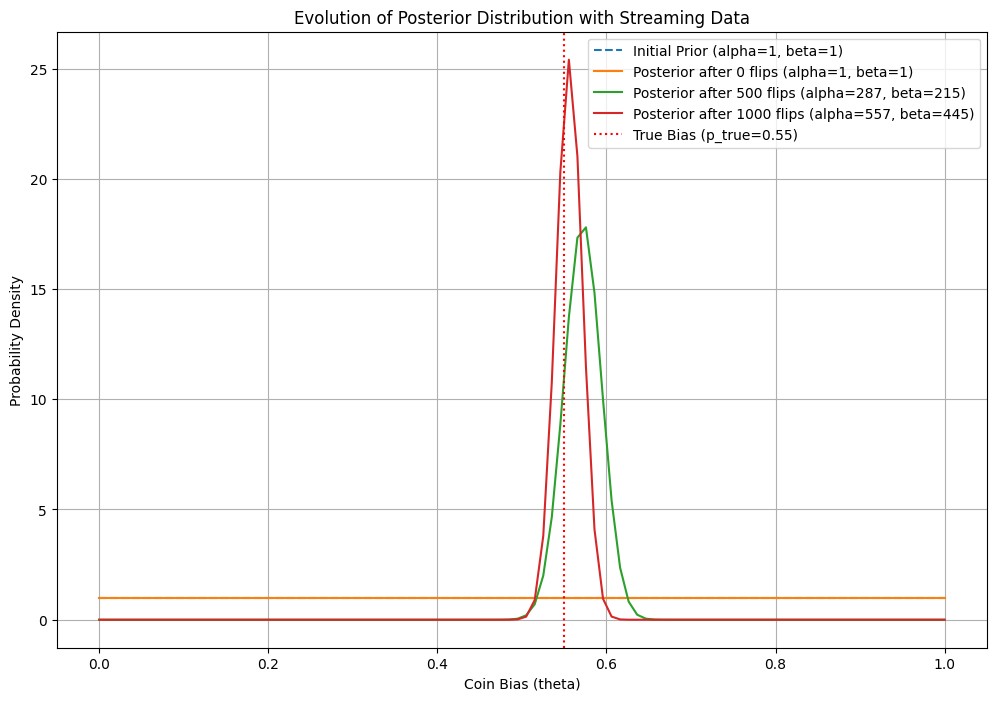

Sequential Bayesian updating visualization complete.


In [ ]:
import matplotlib.pyplot as plt
from scipy.stats import beta

# 8. Define the range of theta values (possible coin biases)
# Reuse the 'theta' array if it's already defined and suitable, otherwise create a new one
# Assuming theta is not available in current scope from previous blocks, so defining it.
theta_seq = np.linspace(0, 1, 100)

# 9. Create a plot to visualize the evolution of the posterior distribution
plt.figure(figsize=(12, 8))

# Plot the initial prior distribution
prior_pdf_seq = beta.pdf(theta_seq, alpha_prior_seq, beta_prior_seq)
plt.plot(theta_seq, prior_pdf_seq, label=f'Initial Prior (alpha={alpha_prior_seq}, beta={beta_prior_seq})', linestyle='--')

# Choose specific points in time to plot posteriors (e.g., after 1 batch, half batches, and final batch)
# We'll plot after 1st batch, middle batch, and final batch
plot_indices = [0, len(alpha_history_seq) // 2, len(alpha_history_seq) - 1]

# Ensure unique and sorted indices
plot_indices = sorted(list(set(plot_indices)))

for i, idx in enumerate(plot_indices):
    current_alpha_plot = alpha_history_seq[idx]
    current_beta_plot = beta_history_seq[idx]
    posterior_pdf_seq = beta.pdf(theta_seq, current_alpha_plot, current_beta_plot)

    # Determine the number of flips accumulated up to this point
    if idx == 0:
        flips_processed = 0 # Prior state
    else:
        flips_processed = (idx) * batch_size # (idx) because alpha_history_seq[0] is prior
        if idx == len(alpha_history_seq) - 1: # Last index might not be a full batch_size multiple
            flips_processed = num_total_flips

    plt.plot(theta_seq, posterior_pdf_seq, label=f'Posterior after {flips_processed} flips (alpha={current_alpha_plot}, beta={current_beta_plot})')

# Add a vertical dashed line at the true coin bias (p_true)
plt.axvline(x=p_true, color='r', linestyle=':', label=f'True Bias (p_true={p_true})')

# Add labels, title, and legend
plt.xlabel('Coin Bias (theta)')
plt.ylabel('Probability Density')
plt.title('Evolution of Posterior Distribution with Streaming Data')
plt.legend()
plt.grid(True)
plt.show()

print("Sequential Bayesian updating visualization complete.")

## Final Task

### Subtask:
Provide a comprehensive summary of the results and insights gained from all implemented post-lab tasks, including observations on integral estimation, MCMC sampling, A/B testing outcomes, efficiency comparisons, and the sequential updating process.


## Summary:

### Data Analysis Key Findings

*   **Monte Carlo Integral Estimation**: The Monte Carlo method successfully estimated the integral of $f(x) = x^2$ over $[0, 1]$ using $1,000,000$ samples. The estimated integral was $0.33295$, closely approximating the true value of $1/3 \approx 0.33333$, with an absolute error of $0.00038$.
*   **Metropolis-Hastings MCMC**: The Metropolis-Hastings algorithm effectively sampled from a target Beta distribution ($\alpha=2, \beta=5$). Using $100,000$ samples, the generated MCMC samples' histogram closely matched the true target probability density function, visually confirming its ability to sample from the target distribution.
*   **Bayesian A/B Testing**:
    *   For simulated conversion rates of Group A ($p_A = 0.04$) and Group B ($p_B = 0.05$) with $1,000$ trials each, Bayesian inference provided posterior distributions.
    *   Based on $39$ conversions for Group A and $55$ for Group B, the posterior distributions yielded mean conversion rates of approximately $0.0399$ for Group A and $0.0558$ for Group B.
    *   There was a high probability of $0.9558$ (95.58%) that Group B's true conversion rate is greater than Group A's.
*   **Comparison of Monte Carlo Efficiencies**:
    *   For integrating $f(x) = x^2$ over $[0, 1]$, Importance Sampling (IS) demonstrated vastly superior accuracy, achieving near-zero absolute errors across sample sizes from $10^3$ to $10^6$. This was due to the use of a proposal distribution proportional to the integrand.
    *   Standard Monte Carlo (SMC) errors, while decreasing with sample size, remained significantly higher than IS errors.
    *   IS incurred a slightly higher execution time than SMC for the same number of samples, attributed to the additional computations required for the proposal probability density function and weights.
*   **Sequential Bayesian Updating**:
    *   A sequential Bayesian process was implemented to update the posterior distribution of a coin's bias ($p_{true} = 0.55$) using streaming data in batches of $50$ flips, for a total of $1,000$ flips.
    *   Starting with a non-informative Beta($\alpha=1, \beta=1$) prior, the final posterior distribution converged to Beta($\alpha=557, \beta=445$), yielding an estimated bias of $557 / (557+445) \approx 0.5559$.
    *   The visualization clearly showed the posterior distribution becoming progressively narrower and more concentrated around the true bias as more data was incorporated, demonstrating the learning process.

### Insights or Next Steps

*   The choice of sampling or proposal distribution significantly impacts the efficiency and accuracy of Monte Carlo methods. For integration, a well-chosen importance sampling distribution can lead to dramatically reduced error with minimal additional computational cost per sample.
*   Bayesian inference provides a robust framework for A/B testing and sequential learning, offering probabilistic statements about the superiority of one variant and continuously updating beliefs as new data arrives, which is particularly valuable in dynamic environments.
